# Revenue Forecasting using Prophet  
### CFO Planning & Financial Forecasting Tool

## Objective
Forecast future revenue using historical transaction data to support:
- Budget planning
- Revenue target setting
- Financial risk management

## Audience
CFOs, Finance Heads, Business Leaders

## Outcome
A data-driven, interpretable forecasting system that provides:
- Forward revenue visibility
- Quantified uncertainty for risk-aware decisions
- Seasonal insights for operational planning


## Why Revenue Forecasting Matters for CFOs

Accurate revenue forecasting enables:
- Proactive budget allocation
- Realistic revenue target setting
- Early identification of financial risk
- Better alignment of expenses with expected cash inflows

This project converts raw transaction data into a
**CFO-ready forecasting and planning tool**.

## Why Prophet?

Prophet is designed for business time-series forecasting.

Key advantages:
- Automatically models trend and seasonality
- Robust to missing dates and irregular time series
- Interpretable components (important for executive decisions)
- Fast to deploy and easy to maintain

Best suited for:
Revenue, demand, and cash-flow forecasting.

# **Install & Import Libraries**

In [1]:
!pip install prophet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12,5)

# **Load Dataset**

In [3]:
df = pd.read_csv("/content/data.csv", encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Business Understanding

This dataset contains **transaction-level sales data**.

To forecast revenue:
1. Calculate revenue per transaction
2. Aggregate revenue by date
3. Forecast future daily revenue

In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Scope & Assumptions

**Dataset**
- UK-based online retail transactions (2010–2011)
- Invoice-level sales data

**Key Assumptions**
- Revenue = Quantity × Unit Price
- Cancelled invoices and negative values are excluded
- Extreme transaction outliers are capped to reduce distortion
- Missing calendar days are interpolated to maintain continuity

**Scope Limitation**
- Forecast applies to historical business patterns
- Structural business changes are not modeled

# **Data Cleaning**

In [8]:
# Remove cancelled invoices
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid financial records
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Remove missing values
df.dropna(subset=["InvoiceDate"], inplace=True)

# Convert date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# **Revenue Calculation**

In [9]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# **Revenue Distribution Check**

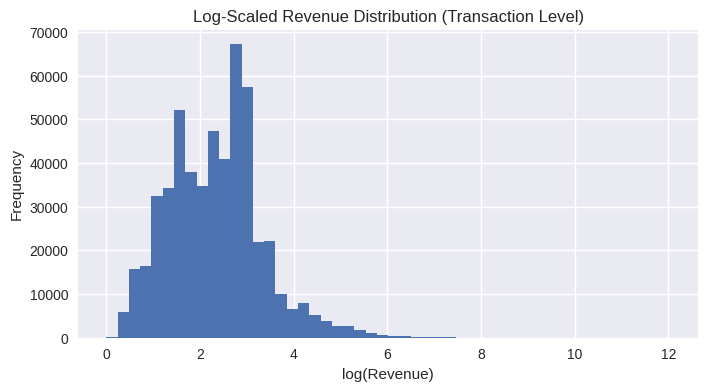

In [10]:
plt.figure(figsize=(8,4))
plt.hist(np.log1p(df["Revenue"]), bins=50)
plt.title("Log-Scaled Revenue Distribution (Transaction Level)")
plt.xlabel("log(Revenue)")
plt.ylabel("Frequency")
plt.show()

# **Outlier Treatment**

In [11]:
# Cap extreme revenue outliers (winsorization)
upper_cap = df["Revenue"].quantile(0.99)
df["Revenue_capped"] = np.where(
    df["Revenue"] > upper_cap,
    upper_cap,
    df["Revenue"]
)

# **Aggregate Daily Revenue**

In [12]:
daily_revenue = (
    df.groupby(df["InvoiceDate"].dt.date)["Revenue_capped"]
    .sum()
    .reset_index()
)

daily_revenue.columns = ["ds", "y"]
daily_revenue.head()

,ds,y
0,2010-12-01,50944.50
1,2010-12-02,40817.97
2,2010-12-03,39859.42
3,2010-12-05,30759.69
4,2010-12-06,48552.13


# **Visualize Historical Revenue**

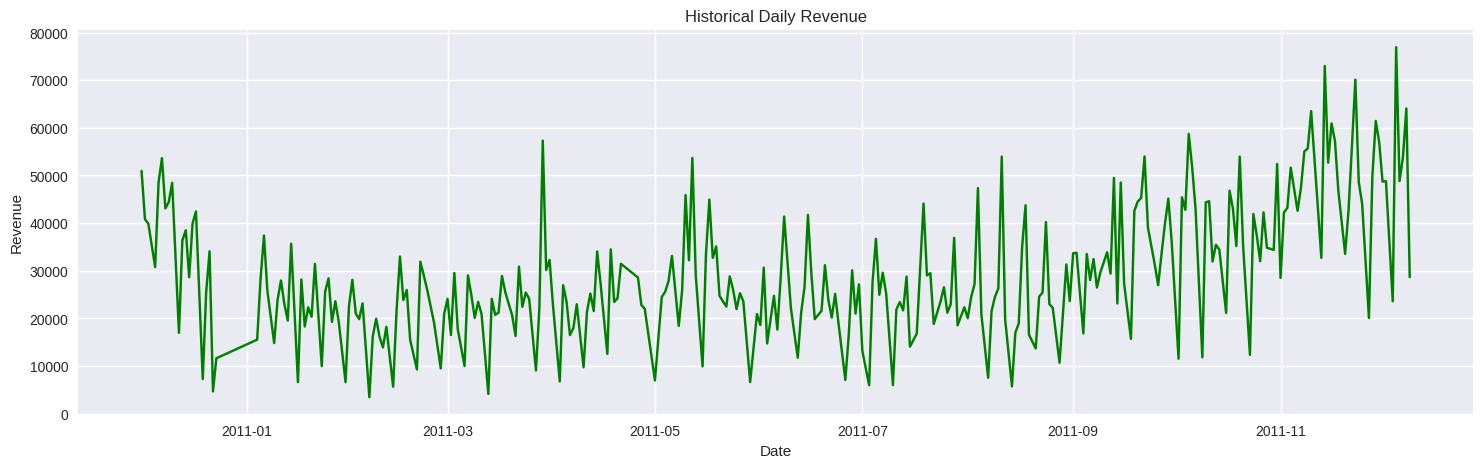

In [13]:
plt.figure(figsize=(18,5))
plt.plot(daily_revenue["ds"], daily_revenue["y"], color = 'green')
plt.title("Historical Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

### Historical Daily Revenue – Key Insights

- Daily revenue shows **high fluctuations**, which is normal in retail businesses.
- Some days have very high sales, while others are much lower.
- Overall revenue **gradually increases toward the end of the year**.
- Daily data is noisy and should not be used alone for decisions.

**Business Meaning:**  
Daily revenue is best used to understand **volatility**, while **monthly trends** are more reliable for planning.


## Why Aggregate Daily Revenue?

CFO decisions are based on:
- Daily / Monthly revenue
- Trends, not individual invoices

Prophet requires:
- `ds` → date
- `y` → numeric value

In [14]:
daily_revenue["ds"] = pd.to_datetime(daily_revenue["ds"])

daily_revenue = (
    daily_revenue
    .set_index("ds")
    .asfreq("D")
    .reset_index()
)

In [15]:
# Interpolate instead of forcing zeros
daily_revenue["y"] = daily_revenue["y"].interpolate(method="linear")

## Why Prophet Is Suitable for This Use Case

Prophet is designed for **business time-series forecasting**, not academic modeling.

It is well-suited because:
- Revenue data shows clear trend and seasonality
- Missing dates and irregular activity are handled gracefully
- Outputs are interpretable for non-technical stakeholders
- Uncertainty intervals support risk-aware decisions

This makes Prophet ideal for **CFO and finance leadership use cases**.

# **Monthly CFO View**

/tmp/ipython-input-180845680.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


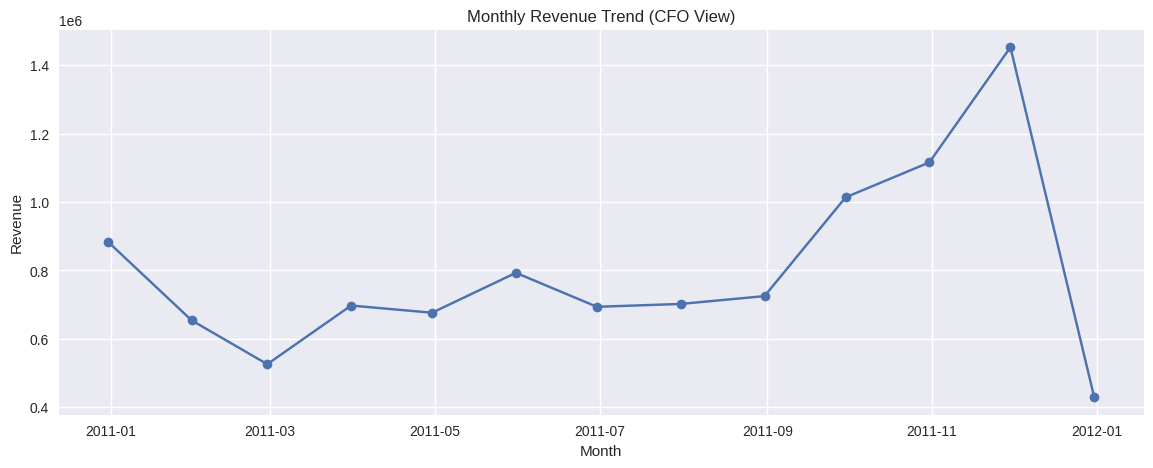

In [16]:
monthly_revenue = (
    daily_revenue
    .set_index("ds")["y"]
    .resample("M")
    .sum()
)

plt.figure(figsize=(14,5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Monthly Revenue Trend (CFO View)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### Monthly Revenue Trend – Key Insights

- Revenue is **not evenly distributed** throughout the year.
- There is a **strong increase in revenue during October–December**.
- The **highest revenue appears in November and December**, indicating peak season.
- Revenue drops sharply in **January**, which is common after holiday sales.
- Mid-year months show **stable but moderate revenue**.

**Business Meaning:**  
Budgeting and revenue targets should be **season-based**, not averaged across the year.

# **Holiday-Aware**

In [17]:
from prophet.make_holidays import make_holidays_df

# Create UK holidays for the full date range in data
uk_holidays = make_holidays_df(
    country='UK',
    year_list=list(range(
        daily_revenue["ds"].dt.year.min(),
        daily_revenue["ds"].dt.year.max() + 1
    ))
)

uk_holidays.head()

,ds,holiday
0,2010-04-02,Good Friday
1,2010-05-03,May Day
2,2010-05-31,Spring Bank Holiday
3,2010-01-01,New Year's Day
4,2010-12-25,Christmas Day


# **Prophet Model Initialization**

In [18]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
    holidays=uk_holidays
)

model.fit(daily_revenue)

# **Create Future Dates**

In [19]:
future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)

# **Forecast Visualization**

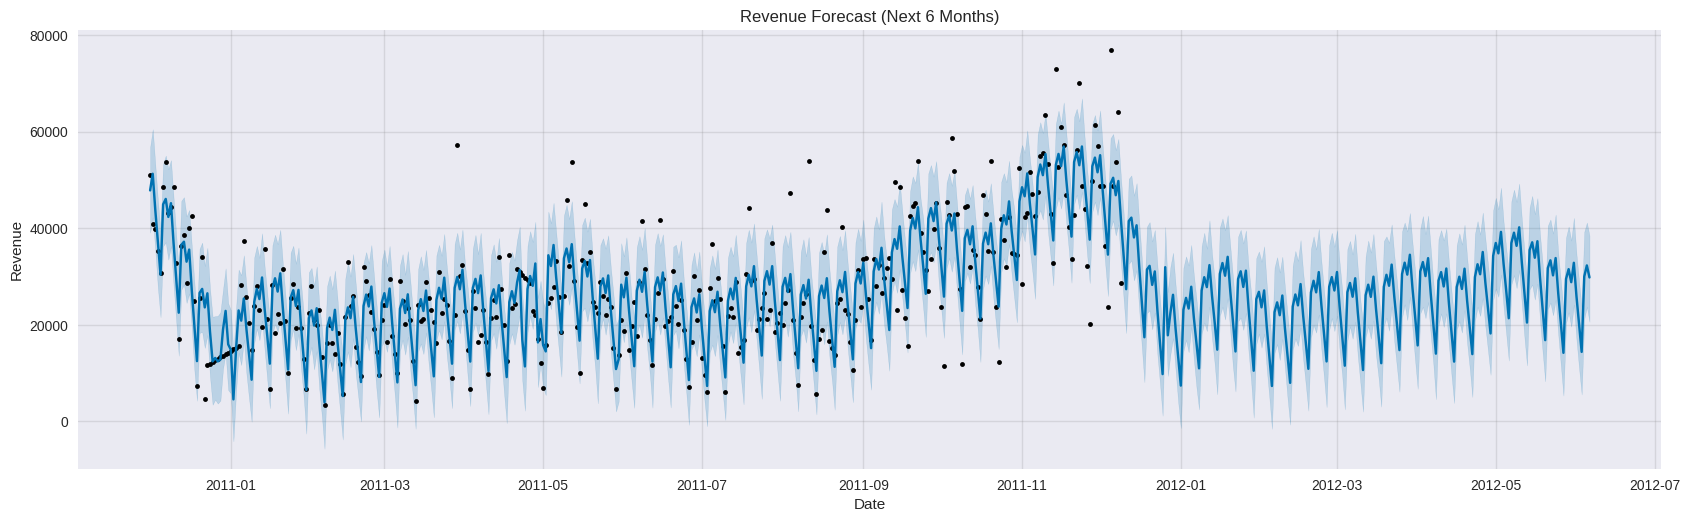

In [20]:
fig = model.plot(forecast)
fig.set_size_inches(18, 5)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Forecast (Next 6 Months)")
plt.show()

# **Seasonality Breakdown**

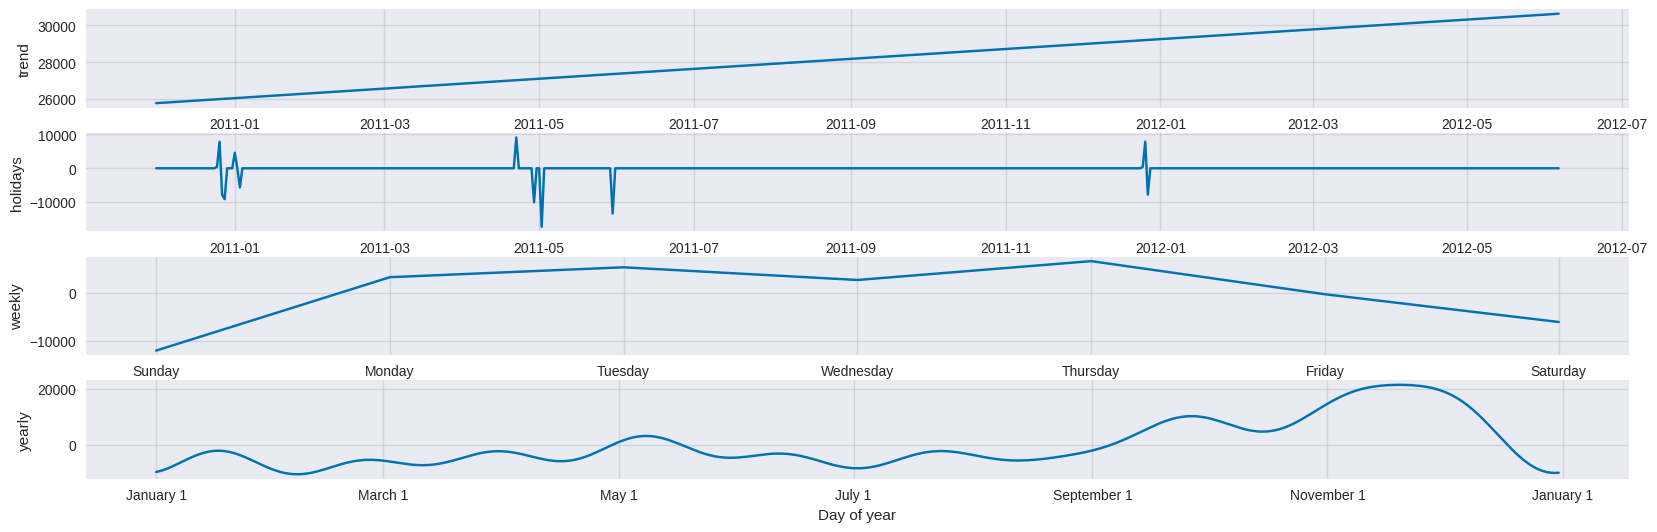

In [21]:
fig = model.plot_components(forecast)
fig.set_size_inches(18, 5)
plt.show()

### Trend Component – Key Insights

- Revenue shows a **steady upward trend** over time.
- Growth is **gradual and consistent**, not sudden.
- No signs of major decline or instability.

**Business Meaning:**  
The business is growing steadily, which supports **long-term planning and controlled investment**.

### Holiday Impact – Key Insights

- Revenue changes noticeably around holiday periods.
- Some holidays increase sales, while others reduce activity.
- Holiday effects are clearly visible in the data.

**Business Meaning:**  
Holiday seasons strongly influence revenue and should be **planned separately in budgets and forecasts**.

### Weekly Seasonality – Key Insights

- Revenue differs across weekdays.
- Some weekdays consistently perform better than others.
- Weekends generally show lower sales.

**Business Meaning:**  
Staffing, promotions, and operations should be **optimized for high-performing weekdays**.

### Yearly Seasonality – Key Insights

- Revenue builds up slowly during the year.
- Sales peak toward the **end of the year**.
- Revenue declines after the holiday season.

**Business Meaning:**  
Year-end contributes the **largest share of annual revenue** and should be a focus area for planning.



## CFO Interpretation Summary

- Forecast includes **trend + seasonality + uncertainty bands**
- Weekly seasonality supports staffing & promotions
- Yearly seasonality supports festival & annual budgeting
- Confidence intervals help assess **financial risk exposure**

This model is suitable for:
- Revenue target planning
- Expense alignment
- Risk-aware budgeting


# **Backtesting (Model Validation)**

In [22]:
train = daily_revenue[:-90]
test = daily_revenue[-90:]

In [23]:
model_bt = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)

model_bt.fit(train)

In [24]:
future_bt = model_bt.make_future_dataframe(periods=90)
forecast_bt = model_bt.predict(future_bt)

# **Error Evaluation**

In [25]:
from sklearn.metrics import mean_absolute_error

y_true = test["y"].values
y_pred = forecast_bt.tail(90)["yhat"].values

mae = mean_absolute_error(y_true, y_pred)
mae

24919.689833170505

In [26]:
# MAPE (excluding zero revenue days)
non_zero_mask = y_true != 0
mape = np.mean(
    np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
) * 100

# WAPE (CFO preferred)
wape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

print(f"WAPE (CFO Preferred Metric): {wape:.2f}%")
print(f"MAPE (Excluding Zero Days): {mape:.2f}%")


WAPE (CFO Preferred Metric): 60.30%
MAPE (Excluding Zero Days): 56.57%


# **Prophet Diagnostics**

In [27]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    model,
    initial="180 days",   # ~6 months
    period="60 days",     # every 2 months
    horizon="60 days"     # 2-month forecast
)

df_perf = performance_metrics(df_cv)
df_perf.head()

INFO:prophet:Making 3 forecasts with cutoffs between 2011-06-12 00:00:00 and 2011-10-10 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,6 days,1.826037e+08,13513.093175,11612.845106,0.682589,0.400096,0.424205,0.277778
1,7 days,1.777019e+08,13330.487493,11581.776878,0.655917,0.296659,0.409611,0.277778
2,8 days,2.229213e+08,14930.550833,12235.259810,0.685890,0.296659,0.411196,0.333333
3,9 days,2.856082e+08,16899.945812,13524.548848,0.654819,0.334786,0.416649,0.333333
4,10 days,3.428702e+08,18516.755663,15234.080315,0.758357,0.355985,0.465164,0.277778


# **CFO-STYLE SUMMARY METRICS**

In [28]:
df_perf.columns

Index(['horizon', 'mse', 'rmse', 'mae', 'mape', 'mdape', 'smape', 'coverage'], dtype='object')

In [29]:
df_perf[["horizon", "mape", "rmse", "mae"]].groupby("horizon").mean()

,mape,rmse,mae
horizon,,,
6 days,0.682589,13513.093175,11612.845106
7 days,0.655917,13330.487493,11581.776878
8 days,0.685890,14930.550833,12235.259810
9 days,0.654819,16899.945812,13524.548848
10 days,0.758357,18516.755663,15234.080315
11 days,0.750410,19503.198314,15786.178285
12 days,0.860571,22368.747582,18163.621118
13 days,0.988499,23674.358049,19958.259897
14 days,1.162201,25818.866051,21979.600518


## Model Evaluation Strategy

The model is evaluated using **out-of-sample backtesting**.

Metrics used:
- **MAPE** – relative forecasting accuracy
- **WAPE** – CFO-preferred weighted error metric
- **RMSE / MAE** – absolute error magnitude

Evaluation is performed over multiple rolling windows
to ensure stability and robustness of results.

# **Best / Worst Case Scenarios**

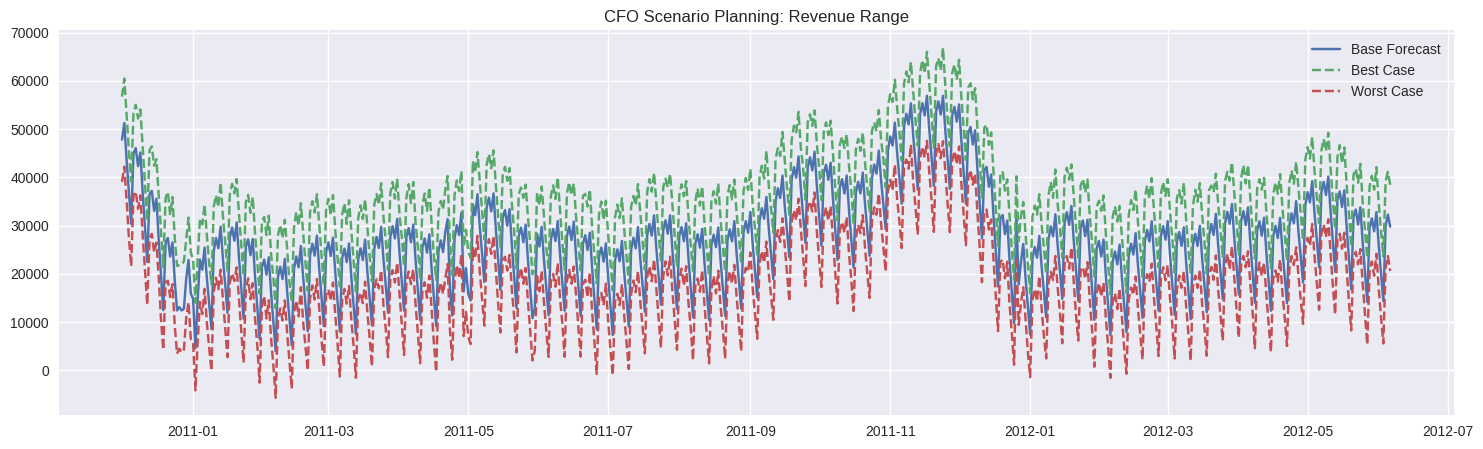

In [30]:
forecast["best_case"] = forecast["yhat_upper"]
forecast["worst_case"] = forecast["yhat_lower"]

plt.figure(figsize=(18,5))
plt.plot(forecast["ds"], forecast["yhat"], label="Base Forecast")
plt.plot(forecast["ds"], forecast["best_case"], linestyle="--", label="Best Case")
plt.plot(forecast["ds"], forecast["worst_case"], linestyle="--", label="Worst Case")
plt.legend()
plt.title("CFO Scenario Planning: Revenue Range")
plt.show()

### Scenario Planning – Revenue Range

- The base forecast shows the **most likely revenue path**.
- The best-case line represents **higher-than-expected performance**.
- The worst-case line shows **downside risk**.
- The gap between lines increases over time, showing **uncertainty in long-term forecasts**.

**Business Meaning:**  
This helps the CFO plan:
- Conservative budgets (worst case)
- Expected targets (base case)
- Growth goals (best case)

# **MAPE (CFO Metric)**

In [31]:
non_zero_mask = y_true != 0
mape = np.mean(
    np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
) * 100

print(f"MAPE (excluding zero-revenue days): {mape:.2f}%")


MAPE (excluding zero-revenue days): 56.57%


# **CFO-Grade KPI**

In [32]:
accuracy = 100 - mape
print(f"Forecast Accuracy: {accuracy:.2f}%")

Forecast Accuracy: 43.43%


## Interpretation of Forecast Accuracy

The observed forecast accuracy reflects:
- High volatility in daily retail revenue
- Sensitivity to promotions and bulk orders
- Limited historical window (~1 year)

For CFO planning:
- The model is best suited for **trend direction and scenario planning**
- Daily precision is less critical than **monthly and quarterly insights**

### Executive Takeaway (CFO Summary)

This forecasting system provides:
- Forward visibility into revenue trends
- Quantified uncertainty for risk-aware budgeting
- Seasonal insights for operational planning

**Outcome:**  
Enables data-driven budgeting, realistic revenue targets, and reduced financial surprises.


## Business Impact & Actionability

This forecasting system enables finance leaders to:

- Set **realistic revenue targets**
- Prepare **best / worst case budget scenarios**
- Identify seasonal peaks for staffing and inventory planning
- Reduce financial surprises through uncertainty-aware forecasts

### Next Steps (Production Readiness)
- Monthly forecasting dashboard (Streamlit)
- Scenario-based budgeting (Best / Base / Worst)
- Integration with ERP or Excel planning models